# Imports

In [1]:
# import muon
import numpy as np
import mudata as md
import scanpy as sc
import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd

# clustering
from sklearn.cluster import KMeans

# Read Data

Working off of the preprocessed tonsil h5mu

In [2]:
# mdata = md.read_h5mu("../../data/tonsil/tonsil_pp.h5mu")
mdata = md.read_h5mu("../../data/tonsil/tonsil_pp_svg.h5mu")

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


In [6]:
# read the embeddings file
embeddings = pd.read_table("../../data/latents/totalvi_k5_1layer_SGC_k1_latents.tsv", header = None, sep = "\t")

# read the umap
umap_rerun = pd.read_table("../../data/latents/totalvi_k5_1layer_SGC_k1_umaplatents.tsv", header = None, sep = "\t")

In [7]:
embeddings = embeddings.to_numpy()
umap_rerun = umap_rerun.to_numpy()

In [17]:
mdata

MuData object with n_obs × n_vars = 2492 × 1267
  2 modalities
    RNA:	2492 x 984
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'
    Protein:	2492 x 283
      obs:	'leiden'
      uns:	'leiden', 'leiden_colors', 'neighbors', 'pca', 'umap'
      obsm:	'X_pca', 'X_umap', 'pos'
      varm:	'PCs'
      obsp:	'connectivities', 'distances'

# Clustering

- Stuff the embeddings into obsm

In [ ]:
## given that embeddings will be an m x k matrix, where m = cells and k = latent dimensions, maybe can pull the mdata object and add the embeddings into obsm layer
rna_adata = mdata.mod['RNA']
rna_adata.obsm['X_spatial_totalVI'] = embeddings
rna_adata.obsm['X_umap']
sc.pp.neighbors(rna_adata, use_rep="X_spatial_totalVI", n_neighbors=30, metric="correlation") # it SHOULD make the umap based on this neighbor's adjacency right?
sc.tl.umap(rna_adata, min_dist=0.4)

prot_adata = mdata.mod['Protein']
prot_adata.obsm['X_spatial_totalVI'] = embeddings
sc.pp.neighbors(prot_adata, use_rep="X_spatial_totalVI", n_neighbors=30, metric="correlation") # it SHOULD make the umap based on this neighbor's adjacency right?
sc.tl.umap(prot_adata, min_dist=0.4)

## K-means

In [16]:
kmeans = KMeans(n_clusters=5, random_state=0).fit(embeddings) # not sure how many clusters to create?
rna_adata.obs['kmeans5'] = kmeans.labels_.astype(str)
prot_adata.obs['kmeans5'] = kmeans.labels_.astype(str)

## Leiden

In [17]:
sc.tl.leiden(rna_adata, key_added="leiden_eval", resolution=0.7, random_state=0)
sc.tl.leiden(prot_adata, key_added="leiden_eval", resolution=0.7, random_state=0)

/var/folders/td/snqs86gn12g5nxg94yl2nhrr0000gn/T/ipykernel_71110/709820832.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(rna_adata, key_added="leiden_eval", resolution=0.7, random_state=0)


## Louvain

In [18]:
sc.tl.louvain(rna_adata, key_added="louvain_eval", resolution=0.7, random_state=0)
sc.tl.louvain(prot_adata, key_added="louvain_eval", resolution=0.7, random_state=0)

# UMAP

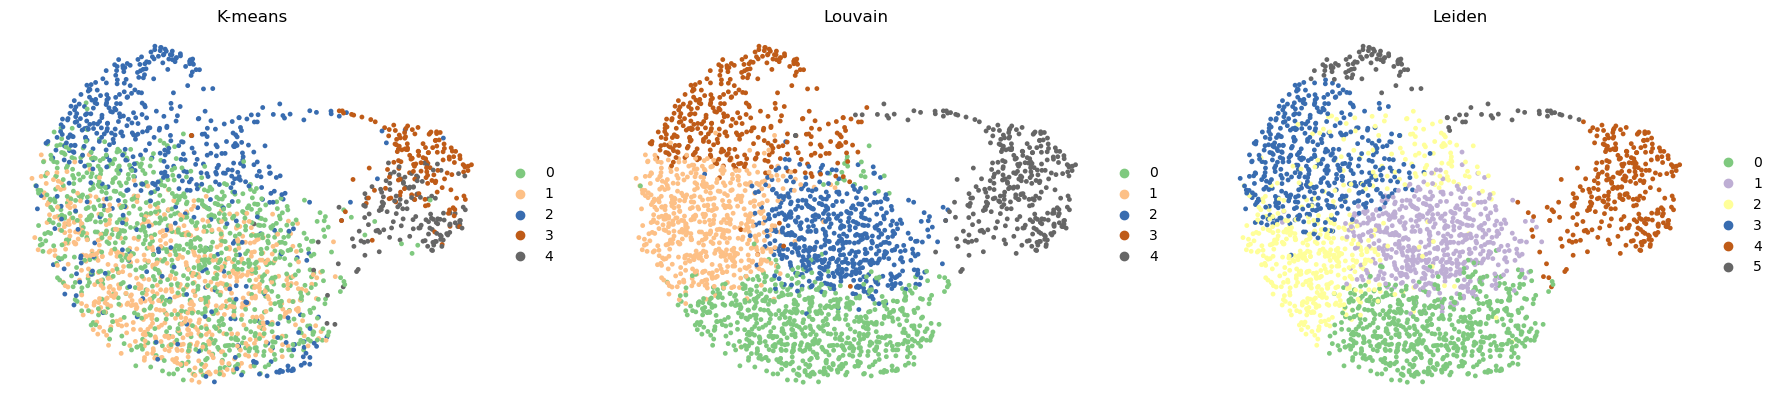

In [ ]:
rna_umap = sc.pl.umap(rna_adata, 
                      color = ['kmeans5', 'louvain_eval', 'leiden_eval'], 
                      frameon = False,
                      palette = 'Accent',
                      title = ['K-means', 'Louvain', 'Leiden'],
                      return_fig=True)

In [39]:
rna_umap.savefig('../results/spatial_totalVI_RNA_UMAP.png', dpi = 300)

In [3]:
mdata = md.read_h5mu("../../data/tonsil/tonsil_embedded.h5mu")

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)


# x-y position plots
- with leiden colours

## RNA

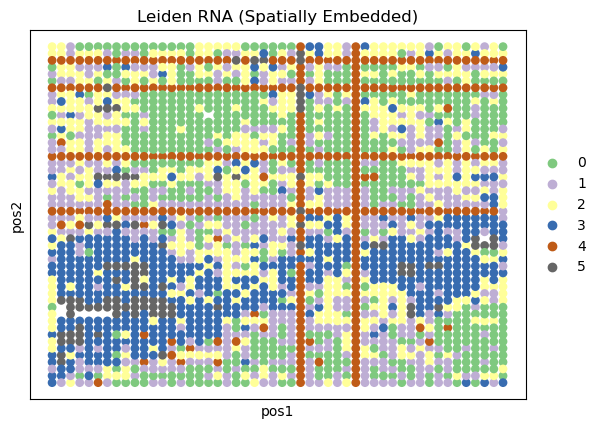

In [12]:
rna_pos_plot = sc.pl.embedding(mdata.mod['RNA'],
                basis="pos",
                color="leiden_eval", 
                s=160,
                return_fig=True,
                title = 'Leiden RNA (Spatially Embedded)',
                palette= "Accent")

In [13]:
rna_pos_plot.set_size_inches(w = 6, h = 6)
rna_pos_plot.savefig("../results/RNA_position_leiden_coloured_plot.pdf", bbox_inches='tight')

# Reassemble h5mu

In [34]:
mdata2 = md.MuData({"RNA": rna_adata, "Protein": prot_adata})
mdata2.write_h5mu("../../data/tonsil/tonsil_embedded.h5mu")

/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("var", axis=0, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1461: FutureWarning: From 0.4 .update() will not pull obs/var columns from individual modalities by default anymore. Set mudata.set_options(pull_on_update=False) to adopt the new behaviour, which will become the default. Use new pull_obs/pull_var and push_obs/push_var methods for more flexibility.
  self._update_attr("obs", axis=1, join_common=join_common)
/opt/anaconda3/lib/python3.13/site-packages/mudata/_core/mudata.py:1598: FutureWarning: From 0.4 .update() will not pull obs/var columns from indivi